# 15 — Importanza delle 16 caratteristiche del ramo prosodico (P) su ASVspoof 2021 DF `eval`

**Domanda.** Quali caratteristiche usa il ramo P per le sue decisioni su `eval`, e quali sostengono i suoi
errori: i falsi negativi (bona fide rifiutati, l'errore dominante di P) o i falsi positivi (spoof accettati)?

**Metodo: ablazione per imputazione.** Per ogni unità si sostituisce il canale con un valore di riferimento,
lasciando intatti gli altri, si ricalcolano i punteggi del checkpoint `model_D_seed0.pt` su tutte le 533.928
prove e si misura la variazione rispetto al modello intatto:
- **ΔEER** (funzione ufficiale): importanza globale. ΔEER > 0 = il modello usava quel canale con profitto;
  ΔEER < 0 = su `eval` quel canale danneggiava.
- **ΔFNR e ΔFPR alla soglia fissa 0 sul logit** (fissata prima, come nel notebook 11): ΔFNR > 0 = il canale
  serviva a **riconoscere i bona fide**; ΔFPR > 0 = serviva a **respingere gli spoof**.
- **Errori corretti e nuovi**: quanti bona fide rifiutati dal modello intatto vengono accettati dopo
  l'ablazione (e viceversa). Dice quali canali **producono** i falsi negativi.
- le stesse misure **per sorgente** (asvspoof, vcc2018, vcc2020).

**Scelte registrate prima dell'esecuzione**
- **Valore di imputazione**: media di ciascun canale nello **spazio preprocessato** (clip e min-max di
  `preproc_prosody.json`, cioè ciò che il modello vede), calcolata sulle sole **finestre valide del train**:
  finestre sonore per le 8 caratteristiche (regola del notebook 04: non tutte e 8 a zero), finestre con
  delta definito per gli 8 delta. **Non zero**: nell'encoding una finestra a zero è una finestra muta (Sez. 6.4).
  Non è la baseline del notebook 12 (non disponibile): il confronto con la classifica di Captum è qualitativo.
- **Due varianti**: `sonore` = imputazione solo dove il canale è valido (misura il valore della caratteristica
  mentre si parla); `tutte` = imputazione su tutte le finestre reali (cancella anche lo schema del silenzio
  di quel canale). La differenza fra le due indica quanto dell'importanza passa dal silenzio.
- **Due unità**: 16 canali singoli e 8 gruppi (caratteristica + suo delta), perché canali correlati possono
  compensarsi e far sottostimare l'importanza del singolo.
- **Incertezza**: bootstrap appaiato stratificato su ΔEER (1.000 repliche) per le prime 5 unità di ciascuna
  delle 4 classifiche, ordinate per |ΔEER|.


In [1]:
import os, re, json, math, time, hashlib, importlib.util, urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, PackedSequence

# --- PERCORSI (gli stessi dei notebook 10 e 11) ------------------------------
BASE_A = Path(os.environ.get("BASE_A", "/kaggle/input/datasets/angelopaldino"))
PROSODY_DIR  = BASE_A / "prosody-features/prosody_features"            # standard_train.npz (notebook 04)
DF_PROS_DIR  = BASE_A / "features/results_Prosodia/df2021/prosodia"    # eval, 533.928 (notebook 11)
DF_KEYS      = BASE_A / "df-keys/CM/trial_metadata.txt"
MODELLI_DIR  = BASE_A / "models/Modelli"
CKPT_P       = MODELLI_DIR / "model_D_seed0.pt"
PREPROC_PROSODIA = MODELLI_DIR / "preproc_prosody.json"
OUT_DIR = Path(os.environ.get("OUT_DIR", "/kaggle/working/ablazione_P"))
SCO_DIR = OUT_DIR / "punteggi"

FEATURES = ["f0_mean", "f0_std", "jitter_local", "shimmer_local",
            "hnr_mean", "hnr_std", "intensity_mean", "intensity_std"]
CANALI = FEATURES + [f"d_{f}" for f in FEATURES]          # ordine della variante D: valori, poi delta
N_CH = len(CANALI)
EMB_DIM, DROPOUT, EVAL_BATCH = 50, 0.2, 256

SOGLIA_FISSA = 0.0          # soglia sul logit fissata a priori (come nel notebook 11)
VARIANTI = ["sonore", "tutte"]
UNITA = {"singolo": {c: [k] for k, c in enumerate(CANALI)},
         "gruppo":  {f: [k, k + len(FEATURES)] for k, f in enumerate(FEATURES)}}
TOP_K = 5
N_BOOT = int(os.environ.get("N_BOOT", 1000))
SEED = 0
MIN_PER_CLASSE = 10

# riferimenti del notebook 11 per il controllo di riproduzione (checkpoint P su eval)
RIF = {"eer_%": 26.83, "FPR_%": 2.83, "FNR_%": 55.42}
TOLL_RIF = 0.05

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
for d in (OUT_DIR, SCO_DIR):
    d.mkdir(parents=True, exist_ok=True)
for nome, p in [("PROSODY_DIR", PROSODY_DIR), ("DF_PROS_DIR", DF_PROS_DIR), ("DF_KEYS", DF_KEYS),
                ("CKPT_P", CKPT_P), ("PREPROC_PROSODIA", PREPROC_PROSODIA)]:
    assert p.exists(), f"{nome} non esiste: {p}"
print(f"device {DEVICE} | torch {torch.__version__} | unita': "
      f"{sum(len(v) for v in UNITA.values())} x {len(VARIANTI)} varianti")

device cuda | torch 2.10.0+cu128 | unita': 24 x 2 varianti


In [2]:
# Metrica ufficiale ASVspoof 2021, identica ai notebook precedenti.
EVAL_METRICS_URL = "https://raw.githubusercontent.com/asvspoof-challenge/2021/main/eval-package/eval_metrics.py"
EVAL_METRICS_PATH = OUT_DIR / "eval_metrics.py"
if not EVAL_METRICS_PATH.exists():
    urllib.request.urlretrieve(EVAL_METRICS_URL, EVAL_METRICS_PATH)
spec = importlib.util.spec_from_file_location("asvspoof_eval_metrics", EVAL_METRICS_PATH)
asv_metrics = importlib.util.module_from_spec(spec); spec.loader.exec_module(asv_metrics)
EVAL_METRICS_SHA256 = hashlib.sha256(EVAL_METRICS_PATH.read_bytes()).hexdigest()
assert EVAL_METRICS_SHA256.startswith("70c5d2fe8fab6654"), EVAL_METRICS_SHA256[:16]


def compute_eer(y, s):
    y, s = np.asarray(y), np.asarray(s, dtype=np.float64)
    return float(asv_metrics.compute_eer(s[y == 1], s[y == 0])[0])


def tassi(y, s, soglia):
    """Convenzione di compute_det_curve ufficiale: accettato come bona fide se punteggio > soglia."""
    y_pred = (np.asarray(s, dtype=np.float64) > soglia).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(np.asarray(y, dtype=np.int8), y_pred, labels=[0, 1]).ravel()
    return {"FPR_%": 100 * fp / (fp + tn), "FNR_%": 100 * fn / (fn + tp), "FP": int(fp), "FN": int(fn)}


def bootstrap_appaiato(y, s_rif, s_alt, n_boot=None, seed=SEED):
    """IC 95% di EER(s_alt) - EER(s_rif) in punti; ricampionamento separato per classe (notebook 13 e 14)."""
    n_boot = n_boot or N_BOOT
    g = np.random.default_rng(seed)
    i_bf, i_sp = np.where(y == 1)[0], np.where(y == 0)[0]
    d = np.empty(n_boot)
    for k in range(n_boot):
        idx = np.concatenate([g.choice(i_bf, len(i_bf)), g.choice(i_sp, len(i_sp))])
        d[k] = compute_eer(y[idx], s_alt[idx]) - compute_eer(y[idx], s_rif[idx])
    d *= 100
    return float(d.mean()), tuple(np.percentile(d, [2.5, 97.5]))


assert compute_eer([1, 1, 0, 0], [2.0, 3.0, 0.0, 1.0]) == 0.0
assert compute_eer([1, 1, 0, 0], [0.0, 1.0, 2.0, 3.0]) == 1.0
print("eval_metrics.py | sha256", EVAL_METRICS_SHA256[:16], "...")

eval_metrics.py | sha256 70c5d2fe8fab6654 ...


In [3]:
# --- preprocessing con le statistiche dell'addestramento (identico al notebook 11) -------------------
PP = json.loads(PREPROC_PROSODIA.read_text())
assert len(PP["clip_lo"]) == N_CH, "preproc_prosody.json non corrisponde alla variante D (16 canali)"
clip_lo, clip_hi = np.array(PP["clip_lo"], np.float32), np.array(PP["clip_hi"], np.float32)
mm_lo, mm_rng = np.array(PP["minmax_lo"], np.float32), np.array(PP["minmax_range"], np.float32)


def voiced_mask(x):
    return np.abs(x).sum(1) > 0


def dynamic_features(x):
    v = voiced_mask(x); n = len(x)
    d_ok = np.zeros(n, dtype=bool); d_ok[1:] = v[1:] & v[:-1]
    d = np.zeros_like(x); d[d_ok] = x[d_ok] - x[np.where(d_ok)[0] - 1]
    return d, d_ok


_x = np.array([[180.], [195.], [170.], [0.], [175.], [190.], [185.]], dtype=np.float32)
assert dynamic_features(_x)[0][:, 0].tolist() == [0, 15, -25, 0, 0, 15, -5]


def preprocessa(x):
    """Restituisce l'ingresso del modello (T, 16) e la maschera di validita' per canale (T, 16)."""
    d, d_ok = dynamic_features(x)
    xd = np.concatenate([x, d], axis=1)
    m = np.concatenate([np.repeat(voiced_mask(x)[:, None], x.shape[1], 1),
                        np.repeat(d_ok[:, None], x.shape[1], 1)], axis=1)
    xc = np.where(m, np.clip(xd, clip_lo, clip_hi), xd)
    return ((xc - mm_lo) / mm_rng).astype(np.float32), m


# --- valori di imputazione: media per canale sulle finestre valide del train ---------------------------
z = np.load(PROSODY_DIR / "standard_train.npz", allow_pickle=True)
Xtr, offtr = z["X"].astype(np.float32), z["offsets"].astype(np.int64)
somma, conta = np.zeros(N_CH, np.float64), np.zeros(N_CH, np.int64)
for i in range(len(offtr) - 1):
    xp, m = preprocessa(Xtr[offtr[i]:offtr[i + 1]])
    somma += np.where(m, xp, 0.0).sum(0); conta += m.sum(0)
assert (conta > 0).all(), conta
MEDIA = (somma / conta).astype(np.float32)
del Xtr
print(f"train: {len(offtr) - 1} file | finestre valide per canale: min {conta.min():,}, max {conta.max():,}")
display(pd.DataFrame({"canale": CANALI, "valore_imputato": MEDIA.round(4),
                      "finestre_valide_train": conta}).set_index("canale"))

train: 25380 file | finestre valide per canale: min 269,271, max 298,510


,valore_imputato,finestre_valide_train
canale,,
f0_mean,0.4208,298510
f0_std,0.0759,298510
jitter_local,0.1391,298510
shimmer_local,0.1866,298510
hnr_mean,0.4612,298510
hnr_std,0.3971,298510
intensity_mean,0.8195,298510
intensity_std,0.3394,298510
d_f0_mean,0.3948,269271


In [4]:
# --- DF eval: chiavi e caratteristiche prosodiche (stessi file del notebook 11) ----------------------
COLS = ["speaker", "utt_id", "codec", "source", "attack", "label", "trim", "subset", "vocoder",
        "c9", "c10", "c11", "c12"]
meta = pd.read_csv(DF_KEYS, sep=r"\s+", header=None, names=COLS, dtype=str, engine="python")
meta = meta[meta["subset"] == "eval"].reset_index(drop=True)
Y = (meta["label"] == "bonafide").astype(np.int8).to_numpy()
assert len(meta) == 533928 and int(Y.sum()) == 14869, (len(meta), int(Y.sum()))
pos = {u: i for i, u in enumerate(meta["utt_id"])}
N = len(meta)

seqs, n_err = [None] * N, 0
for p in sorted(DF_PROS_DIR.glob("pros_*.npz")):
    z = np.load(p, allow_pickle=True)
    X, off = z["X"], z["offsets"].astype(np.int64)
    n_err += int((z["error"] != "").sum())
    for j, u in enumerate(z["utt_id"]):
        if u in pos:
            seqs[pos[u]] = X[off[j]:off[j + 1]]
assert all(s is not None for s in seqs), "caratteristiche prosodiche di eval incomplete"

proc = [preprocessa(s) for s in seqs]
LEN = np.array([len(p[0]) for p in proc], dtype=np.int64)
OFF = np.concatenate([[0], np.cumsum(LEN)]).astype(np.int64)
XP = np.concatenate([p[0] for p in proc]).astype(np.float32)
VALID = np.concatenate([p[1] for p in proc])
del proc, seqs
SRC = meta["source"].to_numpy()
print(f"eval: {N:,} prove | bona fide {int(Y.sum()):,} | finestre {len(XP):,} | errori Praat {n_err} | "
      f"quota di valori validi: canali base {VALID[:, :8].mean():.3f}, delta {VALID[:, 8:].mean():.3f}")

eval: 533,928 prove | bona fide 14,869 | finestre 8,178,444 | errori Praat 0 | quota di valori validi: canali base 0.839, delta 0.757


In [5]:
# --- modello P: classi identiche ai notebook 06.1 e 11 ----------------------------------------------
def masked_bn(x, mask, bn):
    y = torch.zeros_like(x); y[mask] = bn(x[mask]); return y


def map_packed(p, fn):
    return PackedSequence(fn(p.data), p.batch_sizes, p.sorted_indices, p.unsorted_indices)


class SeqBranch(nn.Module):
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.conv1, self.bn_c1 = nn.Conv1d(n_in, 256, kernel_size=3, padding=1), nn.BatchNorm1d(256)
        self.conv2, self.bn_c2 = nn.Conv1d(256, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128)
        self.drop = nn.Dropout(p)
        self.lstm1, self.bn_l1 = nn.LSTM(128, 100, batch_first=True), nn.BatchNorm1d(100)
        self.lstm2, self.bn_l2 = nn.LSTM(100, 50, batch_first=True), nn.BatchNorm1d(50)
        self.att_w, self.att_v = nn.Linear(50, 50), nn.Linear(50, 1, bias=False)

    def conv_block(self, h, conv, bn, mask):
        h = conv(h.transpose(1, 2)).transpose(1, 2)
        h = F.relu(masked_bn(h, mask, bn))
        return self.drop(h) * mask.unsqueeze(-1)

    def forward(self, x, lengths):
        T = x.shape[1]
        mask = torch.arange(T, device=x.device)[None, :] < lengths.to(x.device)[:, None]
        h = self.conv_block(x, self.conv1, self.bn_c1, mask)
        h = self.conv_block(h, self.conv2, self.bn_c2, mask)
        p = pack_padded_sequence(h, lengths.cpu(), batch_first=True, enforce_sorted=False)
        p, _ = self.lstm1(p)
        p = map_packed(map_packed(p, self.bn_l1), self.drop)
        p, _ = self.lstm2(p)
        p = map_packed(p, self.bn_l2)
        H, _ = pad_packed_sequence(p, batch_first=True, total_length=T)
        e = self.att_v(torch.tanh(self.att_w(H))).squeeze(-1)
        a = torch.softmax(e.masked_fill(~mask, float("-inf")), dim=1)
        return (a.unsqueeze(-1) * H).sum(1), a


class ProsodyClassifier(nn.Module):
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.branch = SeqBranch(n_in, p)
        self.head = nn.Sequential(nn.Linear(EMB_DIM, 50), nn.ReLU(), nn.Dropout(p), nn.Linear(50, 1))

    def forward(self, x, lengths):
        z, _ = self.branch(x, lengths)
        return self.head(z).squeeze(-1)


MODEL = ProsodyClassifier(N_CH).to(DEVICE)
MODEL.load_state_dict(torch.load(CKPT_P, map_location=DEVICE), strict=True)
MODEL.eval()
assert sum(p.numel() for p in MODEL.parameters()) == 239645


@torch.no_grad()
def punteggi(X):
    out = []
    for k in range(0, N, EVAL_BATCH):
        idx = np.arange(k, min(k + EVAL_BATCH, N))
        L = LEN[idx]
        B = torch.zeros(len(idx), int(L.max()), N_CH)
        for j, i in enumerate(idx):
            B[j, :L[j]] = torch.from_numpy(X[OFF[i]:OFF[i] + L[j]])
        out.append(MODEL(B.to(DEVICE), torch.from_numpy(L)).float().cpu().numpy())
    return np.concatenate(out).astype(np.float64)


def con_cache(nome, fn):
    f = SCO_DIR / f"{nome}.npy"
    if f.exists():
        return np.load(f)
    s = fn(); np.save(f, s); return s


# --- modello intatto e controllo di riproduzione del notebook 11 -------------------------------------
S0 = con_cache("intatto", lambda: punteggi(XP))
EER0 = 100 * compute_eer(Y, S0)
T0 = tassi(Y, S0, SOGLIA_FISSA)
print(f"P intatto: EER {EER0:.2f}% | soglia {SOGLIA_FISSA}: FPR {T0['FPR_%']:.2f}% FNR {T0['FNR_%']:.2f}%")
for k, v in [("eer_%", EER0), ("FPR_%", T0["FPR_%"]), ("FNR_%", T0["FNR_%"])]:
    assert abs(v - RIF[k]) < TOLL_RIF, f"{k}: {v:.2f} contro {RIF[k]:.2f} del notebook 11"
ACC0 = S0 > SOGLIA_FISSA                          # decisioni del modello intatto
FN0, FP0 = (Y == 1) & ~ACC0, (Y == 0) & ACC0

P intatto: EER 26.83% | soglia 0.0: FPR 2.83% FNR 55.42%


## Ablazioni

48 ablazioni (16 canali + 8 gruppi, × 2 varianti). I punteggi di ciascuna vengono salvati in `punteggi/`
e, alla ripresa, ricaricati invece di essere ricalcolati.

In [6]:
def ablato(canali, variante):
    X = XP.copy()
    for c in canali:
        if variante == "sonore":
            X[VALID[:, c], c] = MEDIA[c]
        else:
            X[:, c] = MEDIA[c]
    return X


righe, righe_src = [], []
t0 = time.perf_counter()
for tipo, unita in UNITA.items():
    for nome, canali in unita.items():
        for var in VARIANTI:
            tag = f"{tipo}__{nome}__{var}"
            s = con_cache(tag, lambda: punteggi(ablato(canali, var)))
            t = tassi(Y, s, SOGLIA_FISSA)
            acc = s > SOGLIA_FISSA
            ds = s - S0
            righe.append({
                "tipo": tipo, "unita": nome, "variante": var,
                "eer_%": 100 * compute_eer(Y, s), "FPR_%": t["FPR_%"], "FNR_%": t["FNR_%"],
                # errori del modello intatto corretti dall'ablazione, ed errori nuovi
                "FN_corretti": int((FN0 & acc).sum()), "FN_nuovi": int(((Y == 1) & ACC0 & ~acc).sum()),
                "FP_corretti": int((FP0 & ~acc).sum()), "FP_nuovi": int(((Y == 0) & ~ACC0 & acc).sum()),
                # spostamento medio del logit per classe (> 0 = verso bona fide)
                "dlogit_bonafide": float(ds[Y == 1].mean()), "dlogit_spoof": float(ds[Y == 0].mean())})
            for src in sorted(np.unique(SRC)):
                m = SRC == src
                if min(int(Y[m].sum()), int((1 - Y[m]).sum())) < MIN_PER_CLASSE:
                    continue
                ts, t0s = tassi(Y[m], s[m], SOGLIA_FISSA), tassi(Y[m], S0[m], SOGLIA_FISSA)
                righe_src.append({"tipo": tipo, "unita": nome, "variante": var, "sorgente": src,
                                  "dEER": 100 * (compute_eer(Y[m], s[m]) - compute_eer(Y[m], S0[m])),
                                  "dFPR": ts["FPR_%"] - t0s["FPR_%"], "dFNR": ts["FNR_%"] - t0s["FNR_%"]})
    print(f"{tipo}: {len(unita) * len(VARIANTI)} ablazioni | {(time.perf_counter() - t0) / 60:.1f} min", flush=True)

ABL = pd.DataFrame(righe)
ABL["dEER"] = ABL["eer_%"] - EER0
ABL["dFPR"] = ABL["FPR_%"] - T0["FPR_%"]
ABL["dFNR"] = ABL["FNR_%"] - T0["FNR_%"]
ABL.to_csv(OUT_DIR / "ablazione_globale.csv", index=False)
SRC_TAB = pd.DataFrame(righe_src)
SRC_TAB.to_csv(OUT_DIR / "ablazione_per_sorgente.csv", index=False)

for tipo in UNITA:
    for var in VARIANTI:
        t = (ABL[(ABL["tipo"] == tipo) & (ABL["variante"] == var)]
             .set_index("unita").sort_values("dEER", ascending=False))
        print(f"\n=== {tipo}, imputazione su finestre {var}: ordinato per dEER "
              f"(EER intatto {EER0:.2f}%, FPR {T0['FPR_%']:.2f}%, FNR {T0['FNR_%']:.2f}%) ===")
        display(t[["eer_%", "dEER", "dFPR", "dFNR", "FN_corretti", "FN_nuovi", "FP_corretti", "FP_nuovi",
                   "dlogit_bonafide", "dlogit_spoof"]].round(3))

singolo: 32 ablazioni | 9.5 min
gruppo: 16 ablazioni | 14.2 min

=== singolo, imputazione su finestre sonore: ordinato per dEER (EER intatto 26.83%, FPR 2.83%, FNR 55.42%) ===


,eer_%,dEER,dFPR,dFNR,FN_corretti,FN_nuovi,FP_corretti,FP_nuovi,dlogit_bonafide,dlogit_spoof
unita,,,,,,,,,,
intensity_std,28.233,1.406,0.014,-2.038,569,266,2456,2529,-0.074,-0.342
f0_std,28.011,1.183,0.011,0.740,100,210,1061,1117,-0.107,0.067
d_intensity_std,28.005,1.177,0.051,-1.823,402,131,1419,1683,-0.030,-0.254
hnr_std,27.366,0.538,0.030,0.962,509,652,2083,2238,-0.319,-0.088
jitter_local,27.245,0.417,0.038,1.076,192,352,1774,1970,-0.029,0.053
d_hnr_mean,27.164,0.336,-0.529,5.495,4,821,2795,51,-0.397,-0.017
shimmer_local,27.124,0.296,-0.213,6.981,447,1485,3852,2745,-0.520,0.079
d_f0_mean,27.076,0.249,-0.185,1.022,43,195,1127,165,-0.109,-0.012
d_f0_std,26.976,0.148,-0.053,0.330,20,69,346,70,-0.038,-0.009



=== singolo, imputazione su finestre tutte: ordinato per dEER (EER intatto 26.83%, FPR 2.83%, FNR 55.42%) ===


,eer_%,dEER,dFPR,dFNR,FN_corretti,FN_nuovi,FP_corretti,FP_nuovi,dlogit_bonafide,dlogit_spoof
unita,,,,,,,,,,
intensity_mean,28.516,1.688,-2.779,42.774,0,6360,14425,1,-2.437,-0.425
intensity_std,28.314,1.486,0.538,-6.268,1096,164,2294,5088,0.081,-0.385
d_intensity_std,27.971,1.143,0.096,-2.065,427,120,1319,1819,-0.014,-0.259
f0_std,27.836,1.008,0.264,-0.686,232,130,637,2009,0.012,0.112
f0_mean,27.709,0.881,0.103,0.343,456,507,1786,2322,-0.157,-0.200
shimmer_local,27.701,0.873,-1.236,16.847,193,2698,7391,977,-0.972,0.003
hnr_mean,27.527,0.699,0.068,-1.695,635,383,2401,2752,-0.321,-0.453
hnr_std,27.198,0.370,1.348,-9.624,1547,116,510,7507,0.141,-0.110
d_hnr_mean,27.164,0.336,-0.527,5.481,4,819,2790,53,-0.396,-0.017



=== gruppo, imputazione su finestre sonore: ordinato per dEER (EER intatto 26.83%, FPR 2.83%, FNR 55.42%) ===


,eer_%,dEER,dFPR,dFNR,FN_corretti,FN_nuovi,FP_corretti,FP_nuovi,dlogit_bonafide,dlogit_spoof
unita,,,,,,,,,,
intensity_std,28.839,2.011,0.089,-2.421,733,373,3131,3594,-0.087,-0.479
f0_std,28.045,1.217,-0.023,0.928,102,240,1212,1094,-0.129,0.063
jitter_local,27.393,0.565,-0.014,1.554,195,426,1999,1928,-0.058,0.074
shimmer_local,27.319,0.491,-0.589,10.707,331,1923,4984,1927,-0.724,0.105
hnr_std,27.057,0.229,-0.204,3.726,434,988,2982,1924,-0.472,-0.039
f0_mean,26.740,-0.087,-0.276,4.008,193,789,2464,1029,-0.213,-0.041
hnr_mean,26.740,-0.087,-0.581,4.540,293,968,4088,1071,-0.526,-0.310
intensity_mean,26.586,-0.242,-0.329,0.827,350,473,3593,1883,0.009,-0.071



=== gruppo, imputazione su finestre tutte: ordinato per dEER (EER intatto 26.83%, FPR 2.83%, FNR 55.42%) ===


,eer_%,dEER,dFPR,dFNR,FN_corretti,FN_nuovi,FP_corretti,FP_nuovi,dlogit_bonafide,dlogit_spoof
unita,,,,,,,,,,
intensity_std,28.833,2.006,0.652,-7.008,1255,213,2805,6189,0.084,-0.532
intensity_mean,28.193,1.365,-2.789,43.009,0,6395,14475,1,-2.467,-0.463
f0_mean,27.917,1.089,-0.025,0.901,432,566,2126,1995,-0.240,-0.209
shimmer_local,27.897,1.069,-1.549,21.084,134,3269,8605,564,-1.186,0.026
f0_std,27.816,0.989,0.223,-0.451,222,155,798,1954,-0.011,0.108
hnr_mean,27.520,0.693,-0.243,1.749,548,808,3696,2436,-0.550,-0.464
jitter_local,27.265,0.437,0.208,0.242,278,314,1516,2595,0.052,0.100
hnr_std,26.981,0.153,1.156,-8.313,1450,214,930,6932,0.007,-0.063


## Incertezza e lettura per sorgente

Bootstrap appaiato su ΔEER per le prime 5 unità di ciascuna classifica (per |ΔEER|). Una differenza è
considerata solo se l'IC 95% esclude lo zero. Circa 4 minuti per ablazione su `eval`.

In [7]:
F_BOOT = OUT_DIR / "bootstrap_top.csv"
boot = pd.read_csv(F_BOOT).to_dict("records") if F_BOOT.exists() else []
fatti = {(r["tipo"], r["unita"], r["variante"]) for r in boot}
t0 = time.perf_counter()
for tipo in UNITA:
    for var in VARIANTI:
        t = ABL[(ABL["tipo"] == tipo) & (ABL["variante"] == var)]
        top = t.reindex(t["dEER"].abs().sort_values(ascending=False).index).head(TOP_K)
        for _, r in top.iterrows():
            if (tipo, r["unita"], var) in fatti:
                continue
            s = np.load(SCO_DIR / f"{tipo}__{r['unita']}__{var}.npy")
            d, (lo, hi) = bootstrap_appaiato(Y, S0, s)
            boot.append({"tipo": tipo, "unita": r["unita"], "variante": var, "dEER": r["dEER"],
                         "dEER_boot": d, "ic_lo": lo, "ic_hi": hi,
                         "esito": "IC esclude lo zero" if lo > 0 or hi < 0 else "IC include lo zero"})
            pd.DataFrame(boot).to_csv(F_BOOT, index=False)
            print(f"  {tipo} {r['unita']} {var}: dEER {d:+.2f} [{lo:+.2f}, {hi:+.2f}] | "
                  f"{(time.perf_counter() - t0) / 60:.1f} min", flush=True)
BOOT = pd.DataFrame(boot)
print("\n=== prime 5 unita' per classifica: dEER con IC 95% (bootstrap appaiato) ===")
display(BOOT.round(3))

# --- per sorgente: le unita' del bootstrap, dove nascono i falsi negativi -----------------------------
sel = SRC_TAB.merge(BOOT[["tipo", "unita", "variante"]], on=["tipo", "unita", "variante"])
for var in VARIANTI:
    print(f"\n=== per sorgente, imputazione su finestre {var} (soglia {SOGLIA_FISSA}) ===")
    display(sel[sel["variante"] == var].pivot_table(index=["tipo", "unita"], columns="sorgente",
                                                     values=["dEER", "dFNR", "dFPR"]).round(2))

# --- quanto dell'importanza passa dal silenzio: differenza fra le due varianti ---------------------------
conf = (ABL.pivot_table(index=["tipo", "unita"], columns="variante", values="dEER")
        .assign(quota_silenzio=lambda d: d["tutte"] - d["sonore"]).sort_values("tutte", ascending=False))
conf.to_csv(OUT_DIR / "confronto_varianti.csv")
print("\n=== dEER: imputazione solo sulle finestre sonore contro tutte le finestre ===")
print("    quota_silenzio = dEER(tutte) - dEER(sonore): parte dell'effetto legata allo schema del silenzio")
display(conf.round(3))

  singolo intensity_std sonore: dEER +1.38 [+1.15, +1.64] | 3.2 min
  singolo f0_std sonore: dEER +1.18 [+1.00, +1.35] | 6.3 min
  singolo d_intensity_std sonore: dEER +1.16 [+0.98, +1.35] | 9.5 min
  singolo hnr_std sonore: dEER +0.52 [+0.35, +0.71] | 12.7 min
  singolo jitter_local sonore: dEER +0.41 [+0.22, +0.58] | 15.9 min
  singolo intensity_mean tutte: dEER +1.69 [+1.45, +1.92] | 19.0 min
  singolo intensity_std tutte: dEER +1.48 [+1.26, +1.68] | 22.2 min
  singolo d_intensity_std tutte: dEER +1.13 [+0.95, +1.31] | 25.3 min
  singolo f0_std tutte: dEER +0.99 [+0.82, +1.16] | 28.4 min
  singolo f0_mean tutte: dEER +0.87 [+0.66, +1.09] | 31.5 min
  gruppo intensity_std sonore: dEER +1.98 [+1.74, +2.23] | 34.5 min
  gruppo f0_std sonore: dEER +1.19 [+1.03, +1.37] | 37.6 min
  gruppo jitter_local sonore: dEER +0.56 [+0.38, +0.75] | 40.7 min
  gruppo shimmer_local sonore: dEER +0.47 [+0.23, +0.68] | 43.8 min
  gruppo intensity_mean sonore: dEER -0.24 [-0.44, -0.05] | 46.9 min
  grupp

,tipo,unita,variante,dEER,dEER_boot,ic_lo,ic_hi,esito
0,singolo,intensity_std,sonore,1.406,1.383,1.151,1.641,IC esclude lo zero
1,singolo,f0_std,sonore,1.183,1.178,0.996,1.352,IC esclude lo zero
2,singolo,d_intensity_std,sonore,1.177,1.157,0.982,1.345,IC esclude lo zero
3,singolo,hnr_std,sonore,0.538,0.521,0.348,0.713,IC esclude lo zero
4,singolo,jitter_local,sonore,0.417,0.411,0.222,0.584,IC esclude lo zero
5,singolo,intensity_mean,tutte,1.688,1.689,1.454,1.923,IC esclude lo zero
6,singolo,intensity_std,tutte,1.486,1.479,1.257,1.681,IC esclude lo zero
7,singolo,d_intensity_std,tutte,1.143,1.126,0.947,1.312,IC esclude lo zero
8,singolo,f0_std,tutte,1.008,0.994,0.821,1.164,IC esclude lo zero
9,singolo,f0_mean,tutte,0.881,0.873,0.658,1.089,IC esclude lo zero



=== per sorgente, imputazione su finestre sonore (soglia 0.0) ===


dEER                     dFNR                  \
sorgente                asvspoof vcc2018 vcc2020 asvspoof vcc2018 vcc2020   
tipo    unita                                                               
gruppo  f0_std             -0.04    2.86    1.59     1.70   -0.05    0.16   
        intensity_mean      1.17   -1.24   -1.49     0.74    1.40    0.35   
        intensity_std       0.78    1.12    1.56    -5.88    2.51    0.38   
        jitter_local       -0.40    0.77    0.03     3.24   -0.34   -0.41   
        shimmer_local       3.42    0.05   -1.71    16.82    2.67    4.95   
singolo d_intensity_std     0.05    0.66    0.41    -3.62    0.45   -0.03   
        f0_std             -0.04    2.62    1.46     1.36   -0.05    0.13   
        hnr_std            -0.04    1.01    0.67     1.17   -0.19    1.81   
        intensity_std       0.72    0.66    1.74    -4.79    1.96    0.10   
        jitter_local       -0.35    0.56   -0.12     2.42   -0.40   -0.54   

                            dFPR                  
sorgente                asvspoof vcc2018 vcc2020  
tipo    unita                                     
gruppo  f0_std             -0.58    0.18   -0.01  
        intensity_mean      1.45   -1.37   -0.11  
        intensity_std       2.71   -0.74   -0.07  
        jitter_local       -1.64    0.65   -0.02  
        shimmer_local      -1.29   -1.01   -0.10  
singolo d_intensity_std     1.08   -0.29    0.00  
        f0_std             -0.42    0.21   -0.00  
        hnr_std            -0.39    0.28   -0.03  
        intensity_std       2.03   -0.66   -0.08  
        jitter_local       -1.44    0.71   -0.02


=== per sorgente, imputazione su finestre tutte (soglia 0.0) ===


dEER                     dFNR                  \
sorgente                asvspoof vcc2018 vcc2020 asvspoof vcc2018 vcc2020   
tipo    unita                                                               
gruppo  f0_mean             0.55    1.11    1.05     1.56    0.32   -0.06   
        f0_std             -0.07    2.61    1.37    -0.58   -0.34   -0.25   
        intensity_mean      2.77    1.40    0.51    72.67    6.22   12.41   
        intensity_std       0.74    0.71    1.59   -13.97    2.09   -0.38   
        shimmer_local       4.17   -0.16   -1.05    34.60    4.23    7.24   
singolo d_intensity_std     0.05    0.61    0.29    -3.99    0.34   -0.10   
        f0_mean             0.53    0.69    0.73     0.63    0.13   -0.13   
        f0_std             -0.04    2.59    1.24    -0.93   -0.34   -0.48   
        intensity_mean      2.19    1.88    1.47    72.30    6.11   12.35   
        intensity_std       0.54    0.61    1.94   -12.13    1.38   -0.67   

                            dFPR                  
sorgente                asvspoof vcc2018 vcc2020  
tipo    unita                                     
gruppo  f0_mean             0.27   -0.12   -0.04  
        f0_std              0.08    0.56    0.03  
        intensity_mean    -10.88   -3.04   -0.34  
        intensity_std       5.65   -0.37   -0.04  
        shimmer_local      -5.31   -1.94   -0.22  
singolo d_intensity_std     1.25   -0.24    0.01  
        f0_mean             0.53    0.11   -0.03  
        f0_std              0.25    0.60    0.04  
        intensity_mean    -10.90   -3.01   -0.33  
        intensity_std       4.72   -0.31   -0.05


=== dEER: imputazione solo sulle finestre sonore contro tutte le finestre ===
    quota_silenzio = dEER(tutte) - dEER(sonore): parte dell'effetto legata allo schema del silenzio


variante                  sonore  tutte  quota_silenzio
tipo    unita                                          
gruppo  intensity_std      2.011  2.006          -0.005
singolo intensity_mean    -0.134  1.688           1.823
        intensity_std      1.406  1.486           0.081
gruppo  intensity_mean    -0.242  1.365           1.607
singolo d_intensity_std    1.177  1.143          -0.034
gruppo  f0_mean           -0.087  1.089           1.177
        shimmer_local      0.491  1.069           0.578
singolo f0_std             1.183  1.008          -0.175
gruppo  f0_std             1.217  0.989          -0.229
singolo f0_mean           -0.330  0.881           1.211
        shimmer_local      0.296  0.873           0.578
        hnr_mean          -0.188  0.699           0.888
gruppo  hnr_mean          -0.087  0.693           0.780
        jitter_local       0.565  0.437          -0.128
singolo hnr_std            0.538  0.370          -0.168
        d_hnr_mean         0.336  0.336           0.000
        jitter_local       0.417  0.317          -0.100
        d_f0_mean          0.249  0.256           0.007
gruppo  hnr_std            0.229  0.153          -0.076
singolo d_f0_std           0.148  0.148           0.000
        d_jitter_local     0.128  0.134           0.007
        d_hnr_std          0.108  0.120           0.012
        d_shimmer_local    0.027  0.020          -0.007
        d_intensity_mean  -0.087 -0.079           0.008

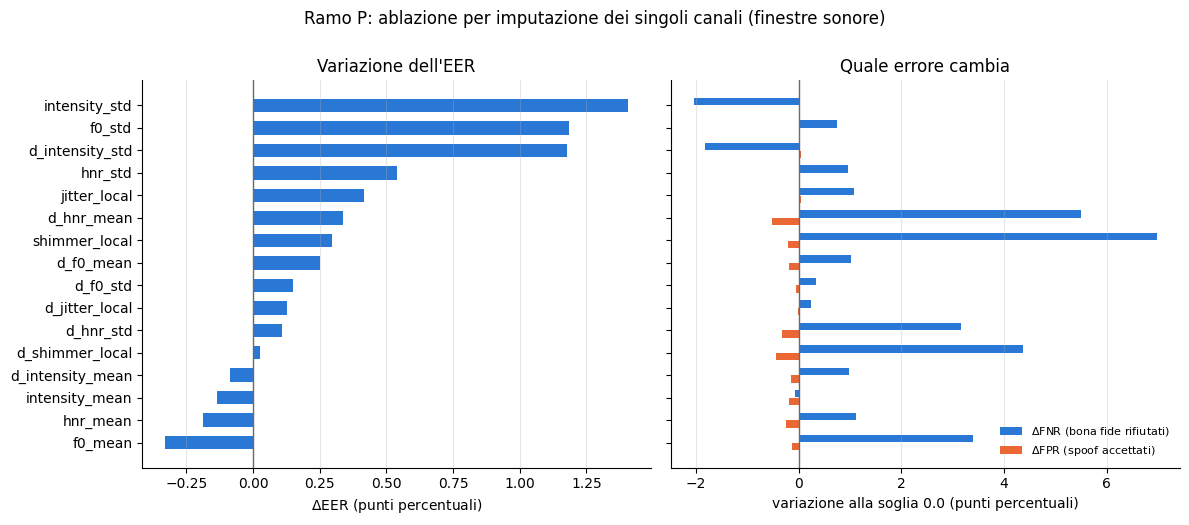

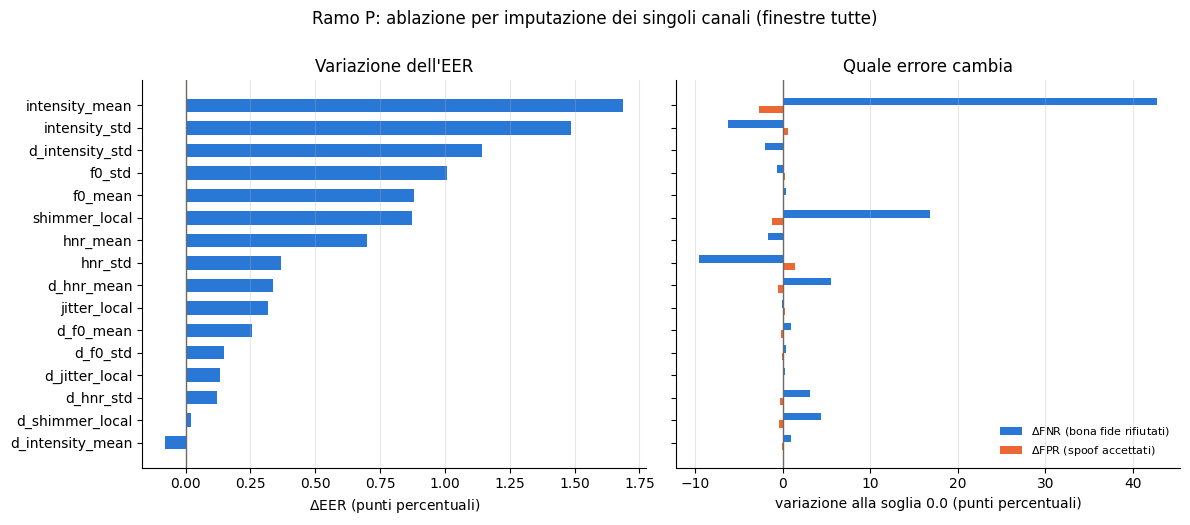

In [8]:
# --- figure: una per variante, canali singoli -------------------------------------------------------
BLU, ARANCIO = "#2a78d6", "#eb6834"     # slot 1 e 2 della palette categoriale di riferimento
for var in VARIANTI:
    t = (ABL[(ABL["tipo"] == "singolo") & (ABL["variante"] == var)]
         .set_index("unita").sort_values("dEER"))
    fig, ax = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True)
    ax[0].barh(t.index, t["dEER"], color=BLU, height=0.6)
    ax[0].axvline(0, color="#6b6a64", lw=1)
    ax[0].set_xlabel(r"$\Delta$EER (punti percentuali)")
    ax[0].set_title("Variazione dell'EER")
    y = np.arange(len(t))
    ax[1].barh(y + 0.17, t["dFNR"], height=0.32, color=BLU, label=r"$\Delta$FNR (bona fide rifiutati)")
    ax[1].barh(y - 0.17, t["dFPR"], height=0.32, color=ARANCIO, label=r"$\Delta$FPR (spoof accettati)")
    ax[1].axvline(0, color="#6b6a64", lw=1)
    ax[1].set_xlabel(f"variazione alla soglia {SOGLIA_FISSA} (punti percentuali)")
    ax[1].set_title("Quale errore cambia")
    ax[1].legend(loc="lower right", fontsize=8, frameon=False)
    for a in ax:
        a.grid(axis="x", alpha=0.3); a.spines[["top", "right"]].set_visible(False)
    fig.suptitle(f"Ramo P: ablazione per imputazione dei singoli canali (finestre {var})", y=1.0)
    plt.tight_layout(); plt.savefig(OUT_DIR / f"fig_ablazione_{var}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [9]:
riepilogo = {
    "dataset": "ASVspoof 2021 DF, sottoinsieme eval (533.928 prove)",
    "modello": str(CKPT_P),
    "riferimento_intatto": {"eer_%": EER0, **{k: T0[k] for k in ("FPR_%", "FNR_%", "FP", "FN")}},
    "soglia_fissa": SOGLIA_FISSA,
    "regola": "bona fide se punteggio > soglia (convenzione di compute_det_curve ufficiale)",
    "imputazione": {"valore": "media per canale nello spazio preprocessato, sulle finestre valide del train",
                    "valori": dict(zip(CANALI, MEDIA.astype(float).round(6))),
                    "varianti": {"sonore": "solo dove il canale e' valido", "tutte": "tutte le finestre reali"}},
    "bootstrap": {"n_boot": N_BOOT, "top_k": TOP_K, "criterio": "|dEER|"},
    "eer_function": {"source": EVAL_METRICS_URL, "sha256": EVAL_METRICS_SHA256},
    "limiti": [
        "un valore costante crea ingressi fuori distribuzione: si misura la sensibilita' del modello, non "
        "l'importanza della caratteristica nel segnale",
        "valore di imputazione diverso dalla baseline del notebook 12: il confronto con Captum e' qualitativo",
        "canali correlati possono compensarsi: l'ablazione del singolo puo' sottostimare l'importanza "
        "(per questo anche i gruppi caratteristica + delta)",
        "un solo seme; nessuna correzione per confronti multipli; IC solo per le prime 5 unita' per classifica",
        "le variazioni di FPR e FNR valgono alla soglia fissa 0, non a quella di EER",
    ]}
(OUT_DIR / "riepilogo.json").write_text(json.dumps(riepilogo, indent=2, default=float))
print("Output:", sorted(p.name for p in OUT_DIR.iterdir() if p.is_file()))

Output: ['ablazione_globale.csv', 'ablazione_per_sorgente.csv', 'bootstrap_top.csv', 'confronto_varianti.csv', 'eval_metrics.py', 'fig_ablazione_sonore.png', 'fig_ablazione_tutte.png', 'riepilogo.json']
